In [1]:
###---Required packages
from Bio import SeqIO
from collections import Counter
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
###---Defining functions

###-------------------1 Loading in a trimmed multi fasta file 
def load_alignment(fasta_path):
    """
    Load a trimmed, aligned multi-FASTA file.

    Parameters
    ----------
    fasta_path : str
        Path to the aligned FASTA file.

    Returns
    -------
    seq_ids : list of str
        Sequence IDs in the alignment.
    seq_strings : list of str
        Aligned sequences as strings.
    """
    sequences = list(SeqIO.parse(fasta_path, "fasta")) #Parse sequences from fasta file
    seq_ids = [record.id for record in sequences] #Extract sequence ids
    seq_strings = [str(record.seq) for record in sequences] #Extract sequence strings 

    return seq_ids, seq_strings

###--------------------2.1 Load in a dataframe assigning ids to species/clade
def load_clade_species_mapping(csv_path):
    """
    Load a CSV mapping sequence IDs to species and clades,
    and return a nested dictionary:
    
    Important!!
    Dataframe should have names: id,species,clade
    
    clade -> species -> list of sequence IDs
    """
    #Load in csv file as dataframe
    df_clade_species = pd.read_csv(csv_path) 
    df_clade_species.columns = [col.lower() for col in df_clade_species.columns] #Decapitalize column names
    
    #Create empty dictionary to fill
    clades_and_species = {} 

    #Check if there are 3 or 2 columns 
    has_clade = "clade" in df_clade_species.columns

    for _, row in df_clade_species.iterrows(): #For every row in the dataframe
        species = row["species"] #Extract Species
        seq_id = row["id"] #Extract ID

        #If 3 columns
        if has_clade:
            clade = row["clade"] #Extract Clade

            #If clade key not in dictionary, add key
            if clade not in clades_and_species: 
                clades_and_species[clade] = {}

            #If species key not in clade dictionary, add key
            if species not in clades_and_species[clade]:
                clades_and_species[clade][species] = []

            #Add seq id as value
            clades_and_species[clade][species].append(seq_id)

        #If 2 columns
        else:
            #If species key not in dictionary, add key
            if species not in clades_and_species:
                clades_and_species[species] = []

            #Add seq id as value
            clades_and_species[species].append(seq_id)

    return clades_and_species

###--------------------2.2 Assign sequences to their respective species/clade in index format
def convert_clade_species_to_indices(clades_and_species, seq_ids):
    """
    Convert a (nested) dictionary of (clades->)species->sequence IDs
    into (clades->)species->alignment indices.

    Parameters
    ----------
    clades_and_species : dict
        Nested dictionary of clade -> species -> list of sequence IDs
        Or
        Dictionary of species -> list of sequence IDs
    seq_ids : list of str
        Sequence IDs in the order they appear in the alignment

    Returns
    -------
    indices_dict : dict
        Nested dictionary of clade -> species -> list of sequence indices
        Or
        Dictionary of Species -> list of sequence indices
    """

    #Define helper function for FASTA - CSV mismatches
    def get_index(seq_id):
        try:
            return seq_ids.index(seq_id)
        except ValueError:
            raise ValueError(f"ERROR: Sequence ID '{seq_id}' From CSV is not found in alignment (FASTA). Check for typos or missing sequences.")
    
    indices_dict = {} #Create empty dictionary

    for key, value in clades_and_species.items():

        #If nested dictionary (Clades present)
        if isinstance(value, dict): #Check if it is a nested dictionary
            species_dict = {} # Create empty dictionary

            for species, seq_list in value.items(): #For every list of seq id's in the species dictionary
                species_dict[species] = [get_index(seq_id) for seq_id in seq_list] #Rename seq id as index in seq_id
            indices_dict[key] = species_dict #Fill the Clade dictionary with the Species dictionary

        #If not nested dictionary (Only species present)
        else:
            indices_dict[key] = [get_index(seq_id) for seq_id in value] #Fill the Species dictionary with renamed seq ids as index in seq id

    return indices_dict

###---------------------3 Converting the columns to an array
def sequences_to_array(seq_strings):
    """
    Convert a list of aligned sequences (strings) to a NumPy array.

    Parameters
    ----------
    seq_strings : list of str
        Aligned sequences as strings.

    Returns
    -------
    alignment_array : np.ndarray
        2D array of shape (n_sequences, n_positions)
        Each cell contains a nucleotide character.
    """
    alignment_array = np.array([list(seq) for seq in seq_strings])
    return alignment_array

###----------------4 Put every column through a filter. Here we filter out sites with gaps, constant sites and SNPs
def get_parsimony_informative_positions(alignment_array):
    """
    Identify parsimony-informative positions in an alignment. Extract descriptive information of positions in alignment
    
    Parameters
    ----------
    alignment_array : np.ndarray
        2D array of aligned sequences (n_sequences × n_positions)
    
    Returns
    -------
    parsimony_informative_positions : list of int
        List of column indices that are parsimony-informative.
    gene_info_dict: dict
        Dictionary containing descriptive information of gene
            Number of positions that:
                Have gaps
                Are constant
                Have a single nucleotide polymorfism (SNP)
                Are parsimony informative (PIS)
            Length
    """
    parsimony_informative_positions = [] #Create empty list
    gap_counter = 0
    constant_counter = 0
    SNP_counter = 0
    PIS_counter = 0

    for position_nr in range(alignment_array.shape[1]): #For every column
        column = alignment_array[:, position_nr] #Take the single column 

        if "-" in column:  # skip gaps
            gap_counter += 1
            continue

        counts = Counter(column)

        if len(counts) == 1:  # skip constant columns
            constant_counter += 1
            continue

        if sum(1 for count in counts.values() if count > 1) < 2:  # skip non-informative SNPs
            SNP_counter += 1                                  
            continue

        parsimony_informative_positions.append(position_nr) #Add position that passed all filters to list 
        PIS_counter += 1                                                                     

    #Calculate total length
    length = gap_counter + constant_counter + SNP_counter + PIS_counter

    #Put information in dictionary
    gene_info_dict = {
        "Gap": gap_counter,
        "Constant": constant_counter,
        "SNP": SNP_counter,
        "PIS": PIS_counter,
        "Length": length
    } 

    return parsimony_informative_positions, gene_info_dict

###--------------------5 Analysis to check if a nucleotide is unique for a species/clade
def find_unique_positions(alignment_array, parsimony_informative_positions, clade_indices, seq_ids):
    """
    Identify nucleotides unique to species or clades at parsimony-informative positions.

    Parameters
    ----------
    alignment_array : np.ndarray
        2D array of aligned sequences (n_sequences × n_positions)
    parsimony_informative_positions : list of int
        List of column indices that are parsimony-informative
    clade_indices : dict
        Nested dictionary of clade -> species -> list of sequence indices
    seq_ids : list of str
        List of sequence IDs in alignment order

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame with columns:
        - Position (1-based)
        - Taxon (species or clade)
        - Nucleotide (unique)
        - Alternative (set of nucleotides in other sequences)
    """
    results = [] #Create empty list 
    threshold = 1.0 #Define the threshold of percentage of taxa within a species/clade to have the same nucleotide 

    for position_nr in parsimony_informative_positions: #For every informative position
        position = position_nr + 1 #Fix index number to actual position in the alignment
        column = alignment_array[:, position_nr] #Take the single column
        # --- Clade-level analysis ---
        for clade, species_dict in clade_indices.items(): #For every Clade:
            clade_indices_list = [i for indices in species_dict.values() for i in indices] #Extract the indices of sequences of members of clade
            clade_states = column[clade_indices_list] #Convert the indices into the actual nucleotides and save them in a 1D numpy array

            counts = Counter(clade_states) #Count the occurence of nucleotides 
            most_common_nt, count = counts.most_common(1)[0] #Identify the most common nucleotide

            if count / len(clade_states) >= threshold: #Check if the clade has the same nucleotide for the required threshold
                clade_unique_nt = most_common_nt #Extract the nucleotide 
                clade_other_indices = [i for i in range(len(seq_ids)) if i not in clade_indices_list] #Extract the alternative nucleotides
                if clade_unique_nt not in column[clade_other_indices]: #If clade nucleotide is not in the alternative nucleotides:
                    results.append({
                        "Position": position,
                        "Taxon": clade,
                        "Nucleotide": clade_unique_nt,
                        "Alternative": set(column[clade_other_indices])
                    })

        # --- Species-level analysis ---
        for clade, species_dict in clade_indices.items(): #For every species dictionary
            for species, indices in species_dict.items(): #For every index number in species dictionary
                species_states = column[indices] #Convert indices into actual nucleotides and save them in a 1D numpy array

                counts = Counter(species_states) #Count the occurence of nucleotides
                most_common_nt, count = counts.most_common(1)[0] #Identify the most common nucleotide

                if count / len(species_states) >= threshold: #Check if the species has the same nucleotide for the required threshold 
                    species_unique_nt = most_common_nt #Extract the nucleotide 
                    species_other_indices = [i for i in range(len(seq_ids)) if i not in indices] #Extract the alternative nucleotides
                    if species_unique_nt not in column[species_other_indices]: #If clade nucleotide is not in the alternative nucleotides:
                        results.append({
                            "Position": position,
                            "Taxon": species,
                            "Nucleotide": species_unique_nt,
                            "Alternative": set(column[species_other_indices])
                        })

    results_df = pd.DataFrame(results)
    return results_df

###---------------6 Convert the per gene results to a row 
def summarize_gene_results(results_df, gene_name):
    """
    Summarize per-gene unique positions into a single-row wide-format DataFrame.

    Parameters
    ----------
    results_df : pd.DataFrame
        Per-gene results with columns: Position, Taxon, Nucleotide, Alternative
    gene_name : str
        Name of the gene

    Returns
    -------
    summary : pd.DataFrame
        One-row DataFrame with taxa as columns and counts of unique positions as values.
    """
    if results_df.empty: #If a gene has no results
        return pd.DataFrame(index=[gene_name]) #Construct a row with no values

    results_df = results_df.copy()
    results_df["Gene"] = gene_name #Add gene name to the results

    summary = ( #Convert the results dataframe into a single row 
        results_df
        .groupby(["Gene", "Taxon"])
        .size()
        .reset_index(name="Count")
        .pivot(index="Gene", columns="Taxon", values="Count")
        .fillna(0)
        .astype(int)
    )

    return summary

###----------------7 Combine all the previous functions in 1 analysis and return a single dataframe
def process_all_genes_from_folder(folder_path, clade_species_csv):
    """
    Process all FASTA files in a folder and combine their unique nucleotide summaries.

    Parameters
    ----------
    folder_path : str
        Path to the folder containing FASTA files.
    clade_species_csv : str
        Path to CSV mapping sequence IDs to species and clades.
        
    Returns
    -------
    final_df : pd.DataFrame
        Rows = genes, Columns = species/clades, values = counts of unique positions.
    all_gene_information : nested dict
        dictionary contains a dictionary for every gene with descriptive information of all positions in alignment
        
    """
    # Load clade/species mapping once
    clades_and_species = load_clade_species_mapping(clade_species_csv)

    # Create empty dictionary for gene information
    all_gene_information = {}                                                                             

    # Define valid file extensions
    valid_extensions = (".fasta", ".fna", ".faa",".ffn")
    
    # Gather all gene files in the folder
    gene_files = {}
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            gene_name = os.path.splitext(filename)[0]
            gene_files[gene_name] = os.path.join(folder_path, filename)

    #Progress meter
    total_genes = len(gene_files)
    step_size = max(1, round(total_genes * 0.025))
    genes_done = 0

    #Create empty list 
    all_gene_summaries = []

    for gene_name, fasta_file in gene_files.items():
        # Step 1: load sequences
        seq_ids, seq_strings = load_alignment(fasta_file)

        # Step 2: convert sequences to array
        alignment_array = sequences_to_array(seq_strings)

        # Step 3: convert clade/species IDs to indices
        clade_indices = convert_clade_species_to_indices(clades_and_species, seq_ids)

        # Step 4: find parsimony-informative positions
        pi_positions, gene_info_dict = get_parsimony_informative_positions(alignment_array)

            #4.5: Extract gene information
        all_gene_information[gene_name] = gene_info_dict                

        # Step 5: find unique positions per gene
        results_df = find_unique_positions(alignment_array, pi_positions, clade_indices, seq_ids)

        # Step 6: summarize per gene
        summary_df = summarize_gene_results(results_df, gene_name)
        
        # Append to list
        all_gene_summaries.append(summary_df)

        #Update progress meter
        genes_done += 1
        if genes_done % step_size == 0 or genes_done == total_genes:
            percentage = genes_done / total_genes
            print(f"{genes_done}/{total_genes} genes completed ({percentage:.1%})")

    # Step 7: combine all gene summaries
    final_df = pd.concat(all_gene_summaries).fillna(0).astype(int)

    return final_df, all_gene_information

In [11]:
###Using function

#------Define path to Folders & Files
folder_path = "Analysis_Folder/"
clade_csv = "Isolates_species_clades.csv"

#------Run the script
final_df, all_gene_information = process_all_genes_from_folder(folder_path, clade_csv)
#final_df.head()

#------Reordering columns in dataframe
final_df = final_df.sort_index(axis=1)
#final_df.head()

#------Convert information nested dictionary to Dataframe
gene_info_df = pd.DataFrame.from_dict(all_gene_information, orient='index')

#------Saving dataframe to csv file
final_df.to_csv("Gene_Analysis_new.csv", index=True)
gene_info_df.to_csv("Gene_Information.csv", index=True)

In [17]:
###Define criteria for good marker genes

###-----Add columns with informative data on the rows: Sum, mean, median, number of taxa with unique positions and length 

#------Check if any taxa dominate the diagnostic positions
taxon_sums = final_df.sum(axis=0)
taxon_means = final_df.mean(axis=0)
taxon_medians = final_df.median(axis=0)
skew_check_df = pd.DataFrame([taxon_sums, taxon_means, taxon_medians], index=["Total", "Average", "Median"])
easy_taxa = taxon_means[(taxon_means >= 1) & (taxon_medians >= 1)].index.tolist()
print(easy_taxa)
print(skew_check_df.head())

#------Exclude high occurence (easy taxa) from part of analysis
nonskew_df = final_df.drop(columns=easy_taxa)

#------Calculating Sum of diagnostic positions------
gene_info_df["Sum"] = final_df.sum(axis=1)
gene_info_df["Hard_Sum"] = nonskew_df.sum(axis=1)

#------Calculating Mean of diagnostic positions that are not 0--------
means = []
for _, row in final_df.iterrows():
    non_zero = row[row > 0]

    if len(non_zero) == 0:
        means.append(0)
    else:
        means.append(non_zero.mean())

hard_means = []
for _, row in nonskew_df.iterrows():
    non_zero = row[row > 0]

    if len(non_zero) == 0:
        hard_means.append(0)
    else:
        hard_means.append(non_zero.mean())

gene_info_df["Mean_nonzero"] = means
gene_info_df["Hard_Mean_nonzero"] = hard_means

#------Calculating Median of diagnostic positions that are not 0--------
medians = []
for _, row in final_df.iterrows():
    non_zero = row[row > 0]      # keep only values > 0

    if len(non_zero) == 0:
        medians.append(0)
    else:
        medians.append(non_zero.median())

hard_medians = []
for _, row in nonskew_df.iterrows():
    non_zero = row[row > 0]      # keep only values > 0

    if len(non_zero) == 0:
        hard_medians.append(0)
    else:
        hard_medians.append(non_zero.median())

gene_info_df["Median_nonzero"] = medians
gene_info_df["Hard_Median_nonzero"] = hard_medians

#------Calculating Number of Taxa with a value of 1 or more--------
gene_info_df["N_taxa"] = (final_df > 0).sum(axis=1)
gene_info_df["Hard_N_taxa"] = (nonskew_df > 0).sum(axis=1)

#------Calculating log(sum)-----------------
gene_info_df["LogSum"] = np.log1p(gene_info_df["Sum"])
gene_info_df["Hard_LogSum"] = np.log1p(gene_info_df["Hard_Sum"])

#------Calculating the diagnostic/parsimony informative ratio
gene_info_df["Diag_PIS_ratio"] = gene_info_df["Sum"]/gene_info_df["PIS"]

#------Calculating the Score--------
gene_info_df["Final_Score"] = (
    gene_info_df["Median_nonzero"] *
    gene_info_df["N_taxa"] *
    gene_info_df["LogSum"] *
    gene_info_df["Diag_PIS_ratio"]
) / gene_info_df["Length"]

gene_info_df["Hard_Final_Score"] = (
    gene_info_df["Hard_Median_nonzero"] *
    gene_info_df["Hard_N_taxa"] *
    gene_info_df["Hard_LogSum"] *
    gene_info_df["Diag_PIS_ratio"]
) / gene_info_df["Length"]

print(gene_info_df.head())

#-----Define minimum median for good markers
MIN_MEDIAN = gene_info_df["Median_nonzero"].quantile(0.5) #Define a minimum minimum median
print(f"The minimal median is: {MIN_MEDIAN}")
hard_MIN_MEDIAN = gene_info_df["Hard_Median_nonzero"].quantile(0.5) #Define a minimum minimum median
print(f"The minimal hard median is: {hard_MIN_MEDIAN}")

#-----Define minimum Number of taxa with diagnostic positions for good markers
MIN_TAXA = gene_info_df["N_taxa"].quantile(0.5) #Define a minimum N_taxa
print(f"The minimal N_taxa is: {MIN_TAXA}")
hard_MIN_TAXA = gene_info_df["Hard_N_taxa"].quantile(0.5) #Define a minimum N_taxa
print(f"The minimal hard N_taxa is: {hard_MIN_TAXA}")

#-----Define minimum ratio of parsimony informative sites to be diagnostic
MIN_ratio = gene_info_df["Diag_PIS_ratio"].quantile(0.75)
print(f"The minimal diag/pis ratio is: {MIN_ratio}")

#-----Selecting potential strong marker genes 
potential_markers = gene_info_df[(gene_info_df["N_taxa"] >= MIN_TAXA) & 
                                (gene_info_df["Median_nonzero"] >= MIN_MEDIAN) & 
                                (gene_info_df["Diag_PIS_ratio"] >= MIN_ratio)].copy()
print(f"The number of potential markers is: {len(potential_markers)}")
hard_potential_markers = gene_info_df[(gene_info_df["Hard_N_taxa"] >= hard_MIN_TAXA) &
                                    (gene_info_df["Hard_Median_nonzero"] >= hard_MIN_MEDIAN) &
                                    (gene_info_df["Diag_PIS_ratio"] >= MIN_ratio)].copy()
print(f"The number of hard potential markers is: {len(hard_potential_markers)}")

###------Select top 100 genes by Final score
top_genes_index = (
    potential_markers["Final_Score"] #Dataframe and Column you wish to select out of 
    .sort_values(ascending=False) #Sort High -> low 
    .head(100) #Take only the top 100
)

hard_top_genes_index = (
    hard_potential_markers["Hard_Final_Score"] #Dataframe and Column you wish to select out of 
    .sort_values(ascending=False) #Sort High -> low 
    .head(100) #Take only the top 100
)

###--------Extracting a combination of genes that together have unique positions for every taxon (Preffered)
top_genes_list = top_genes_index.index.tolist()  # genes ordered by final score
selected_genes = []
covered_taxa = set()

for gene in top_genes_list:
    # taxa this gene uniquely contributes
    new_taxa = set(final_df.columns[final_df.loc[gene] > 0]) - covered_taxa
    if new_taxa:
        selected_genes.append(gene)
        covered_taxa.update(new_taxa)
    if len(covered_taxa) == len(final_df.columns):
        break

hard_top_genes_list = hard_top_genes_index.index.tolist()  # genes ordered by final score
hard_selected_genes = []
hard_covered_taxa = set()

for gene in hard_top_genes_list:
    # taxa this gene uniquely contributes
    new_taxa = set(final_df.columns[final_df.loc[gene] > 0]) - hard_covered_taxa
    if new_taxa:
        hard_selected_genes.append(gene)
        hard_covered_taxa.update(new_taxa)
    if len(hard_covered_taxa) == len(final_df.columns):
        break

print("Selected genes:", selected_genes)
print("Hard Selected genes:", hard_selected_genes)

###---------Identify the weakest taxa and add a gene supporting them best (Suggested!)
current_support = final_df.loc[selected_genes].sum(axis=0)
exclude_taxa = {"Clade_2", "Clade_3"} #Taxa you might not want extra support for 
weak_taxa = (
    current_support
    .drop(labels=exclude_taxa, errors="ignore")
    .sort_values()
    .head(2) #Take the 2 weakest taxa
    .index
)

hard_current_support = final_df.loc[hard_selected_genes].sum(axis=0)
hard_exclude_taxa = {"Clade_2", "Clade_3"} #Taxa you might not want extra support for 
hard_weak_taxa = (
    hard_current_support
    .drop(labels=hard_exclude_taxa, errors="ignore")
    .sort_values()
    .head(2) #Take the 2 weakest taxa
    .index
)

print("Weak taxa used for selection:", weak_taxa.tolist())
print("Weak taxa used for hard selection:", hard_weak_taxa.tolist())

#---------Identify ids of the genes not yet selected
remaining_genes = final_df.index.difference(selected_genes)
gene_scores = (
    final_df.loc[remaining_genes, weak_taxa] #Create dataframe of the remaining genes as rows and the weak taxa as columns
    .sum(axis=1) 
)
best_gene = gene_scores.idxmax() #Best gene is the id with the highest sum for the weak taxa 

hard_remaining_genes = final_df.index.difference(hard_selected_genes)
hard_gene_scores = (
    final_df.loc[hard_remaining_genes, hard_weak_taxa] #Create dataframe of the remaining genes as rows and the weak taxa as columns
    .sum(axis=1) 
)
hard_best_gene = hard_gene_scores.idxmax() #Best gene is the id with the highest sum for the weak taxa 

print("Best gene to strengthen weak taxa:", best_gene)
print("Best gene to strengthen hard weak taxa:", hard_best_gene)

selected_genes.append(best_gene) #Add gene to selection 
final_selection = selected_genes.copy()
print(f"The final selection is: {final_selection}")
print(f"The final selection consists of {len(final_selection)} genes")

hard_selected_genes.append(hard_best_gene) #Add gene to selection 
hard_final_selection = hard_selected_genes.copy()
print(f"The final hard selection is: {hard_final_selection}")
print(f"The final hard selection consists of {len(hard_final_selection)} genes")

['Clade_1', 'Contaminatum', 'Kalimantanense', 'Odoratissimum']
             Clade_1    Clade_2    Clade_3  Contaminatum  Cugenangense  \
Total    5105.000000  125.00000  57.000000   4497.000000    319.000000   
Average     2.047734    0.05014   0.022864      1.803851      0.127958   
Median      1.000000    0.00000   0.000000      1.000000      0.000000   

           Curvatum  Gossypinum  Hexaseptatum      Hoodiae  Kalimantanense  \
Total    366.000000   73.000000     35.000000  1194.000000    11625.000000   
Average    0.146811    0.029282      0.014039     0.478941        4.663057   
Median     0.000000    0.000000      0.000000     0.000000        3.000000   

         Languescens  Nirenbergiae  Odoratissimum   Oxysporum  \
Total    2416.000000   1112.000000    5105.000000  141.000000   
Average     0.969114      0.446049       2.047734    0.056558   
Median      1.000000      0.000000       1.000000    0.000000   

         Tardichlamydosporum  Triseptatum  Undescribed1  Undescrib

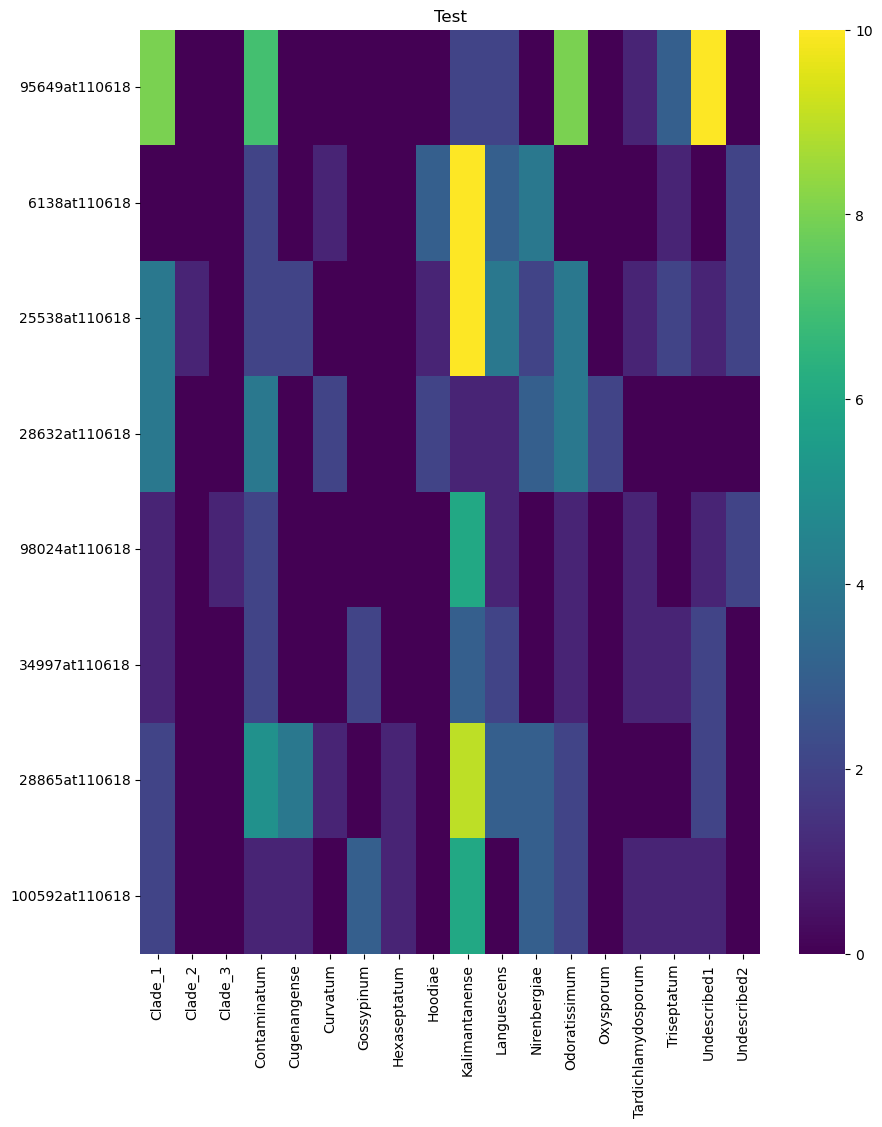

In [20]:
subset = final_df.loc[hard_final_selection] 

#Plot the heatmap 
plt.figure(figsize=(10, 12))
sns.heatmap(subset, 
            cmap="viridis",
            vmax=10) #Max number for color distribution
plt.title("Test")
plt.show()

In [ ]:
###Make a txt file from selection
genes2txt = final_genes
extension = "_MSA_trimmed.fna"
output_file = "6selected_genes_Finalscore_Minimal_weaktaxa.txt"

#---------Save the filenames to a text file
with open(output_file, "w") as f:
    for gene in genes2txt:
        f.write(f"{gene}{extension}\n")

In [4]:
###---------------Reading csv file back in as dataframe ( Saves Rerunning on restart )
final_df = pd.read_csv("Gene_Analysis_new.csv", index_col=0)
gene_info_df = pd.read_csv("Gene_Information.csv", index_col=0)
final_df.head()
gene_info_df.head()


,Gap,Constant,SNP,PIS,Length
19723at110618,0,1163,20,74,1257
108670at110618,0,616,16,37,669
43350at110618,0,643,56,72,771
121934at110618,0,1396,40,142,1578
63699at110618,0,1822,37,112,1971
